# 1. Mount Drive & Install Requirements

## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/users/')

Mounted at /users/


## Install Required Libraries

In [ ]:
!pip install pandas numpy seaborn matplotlib plotly scikit-learn python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 9.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import os
from sklearn.feature_selection import VarianceThreshold
from docx import Document
from docx.shared import Inches

# 2. Dataset Loading & Basic Structure

## Dataset Path & File Structure Overview

In [ ]:
base_path = "/users/"

print("📂 Folder structure for CIC-BCCC-NRC-IoMT-2024:\n")
for root, dirs, files in os.walk(base_path):
    print(root, " --> ", files)

📂 Folder structure for CIC-BCCC-NRC-IoMT-2024:

/users/  -->  ['DDoS ICMP Flood.csv', 'DoS ICMP Flood.csv', 'DDoS UDP Flood.csv', 'DoS TCP Flood.csv', 'Benign Traffic.csv', 'MITM ARP Spoofing.csv', 'DoS UDP Flood.csv', 'MQTT DDoS Publish Flood.csv', 'MQTT Malformed.csv', 'MQTT DoS Publish Flood.csv', 'Recon OS Scan.csv', 'MQTT DoS Connect Flood.csv', 'Recon Port Scan.csv', 'Recon Vulnerability Scan.csv', 'Recon Ping Sweep.csv', 'index.html', 'index.html?C=N;O=D', 'index.html?C=M;O=A', 'index.html?C=S;O=A', 'index.html?C=D;O=A', 'index.html?C=N;O=A', 'index.html?C=M;O=D', 'index.html?C=S;O=D', 'index.html?C=D;O=D']


## Load CSV File

In [ ]:
csv_files = [f for f in os.listdir(base_path) if f.lower().endswith(".csv")]
print("📌 Found CSV files:")
for f in csv_files:
    print(" -", f)

df_list = []

for file in csv_files:
    file_path = os.path.join(base_path, file)

    # Extract label from filename (remove .csv)
    label = file.replace(".csv", "")

    temp_df = pd.read_csv(file_path)
    temp_df["Label"] = label  # assign class
    df_list.append(temp_df)

# Merge all into one
df = pd.concat(df_list, ignore_index=True)

print("\n✅ Final merged dataset loaded!")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

📌 Found CSV files:
 - DDoS ICMP Flood.csv
 - DoS ICMP Flood.csv
 - DDoS UDP Flood.csv
 - DoS TCP Flood.csv
 - Benign Traffic.csv
 - MITM ARP Spoofing.csv
 - DoS UDP Flood.csv
 - MQTT DDoS Publish Flood.csv
 - MQTT Malformed.csv
 - MQTT DoS Publish Flood.csv
 - Recon OS Scan.csv
 - MQTT DoS Connect Flood.csv
 - Recon Port Scan.csv
 - Recon Vulnerability Scan.csv
 - Recon Ping Sweep.csv

✅ Final merged dataset loaded!
Shape: (3385313, 85)
Columns: ['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'F

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack Name,Label
0,54.164.8.26-192.168.137.174-443-50634-6,54.164.8.26,443,192.168.137.174,50634,6,06/09/2023 02:00:42 PM,386988,25,42,...,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.0,0.0,DDoS ICMP Flood,DDoS ICMP Flood
1,13.225.193.148-192.168.137.174-443-39086-6,13.225.193.148,443,192.168.137.174,39086,6,06/09/2023 02:00:51 PM,18583,3,0,...,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.0,0.0,DDoS ICMP Flood,DDoS ICMP Flood
2,13.225.193.148-192.168.137.174-443-39086-6,13.225.193.148,443,192.168.137.174,39086,6,06/09/2023 02:00:51 PM,164448,1,3,...,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.0,0.0,DDoS ICMP Flood,DDoS ICMP Flood
3,34.173.20.6-192.168.137.174-443-47304-6,34.173.20.6,443,192.168.137.174,47304,6,06/09/2023 02:00:36 PM,59949896,8,3,...,131709.333333,586.457444,132198.0,131059.0,14871682.75,108646.118192,14926518.0,14708716.0,DDoS ICMP Flood,DDoS ICMP Flood
4,192.168.137.174-34.173.20.6-47304-443-6,192.168.137.174,47304,34.173.20.6,443,6,06/09/2023 02:01:36 PM,1224,4,0,...,0.000000,0.000000,0.0,0.0,0.00,0.000000,0.0,0.0,DDoS ICMP Flood,DDoS ICMP Flood


# 3. TARGET VARIABLE ANALYSIS

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)

print("🔍 Missing Values in Each Column:\n")
missing[missing > 0]

🔍 Missing Values in Each Column:



,0


## Duplicate Row Analysis

In [ ]:
duplicate_count = df.duplicated().sum()

print("🔍 Total Duplicate Rows:", duplicate_count)

🔍 Total Duplicate Rows: 109180


## Attack Class Distribution (Counts + Bar Plot)

In [ ]:
print("📊 Class Distribution:\n")
print(df["Label"].value_counts())

📊 Class Distribution:

Label
DoS TCP Flood               2106916
Recon Port Scan              485522
MQTT DDoS Publish Flood      413913
MQTT DoS Connect Flood       238031
Recon OS Scan                 85317
Benign Traffic                32620
Recon Vulnerability Scan       8321
DoS UDP Flood                  3115
DDoS UDP Flood                 2576
DDoS ICMP Flood                2552
MQTT Malformed                 2246
DoS ICMP Flood                 2107
MITM ARP Spoofing              1053
MQTT DoS Publish Flood          953
Recon Ping Sweep                 71
Name: count, dtype: int64


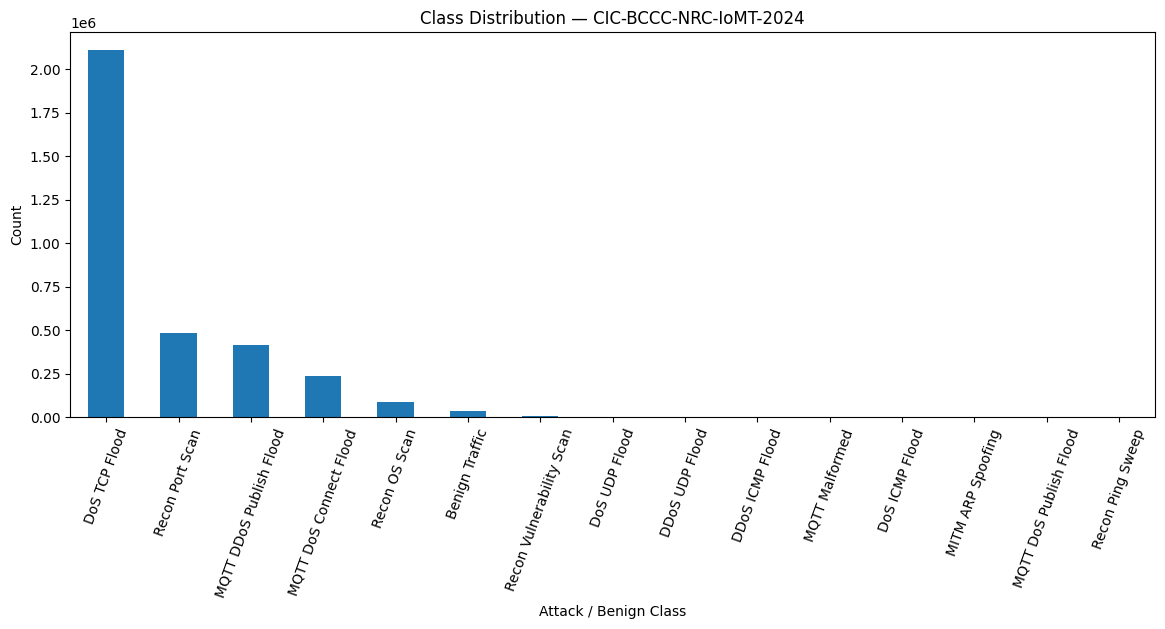

In [ ]:
df["Label"].value_counts().plot(
    kind="bar",
    figsize=(14,5),
    title="Class Distribution — CIC-BCCC-NRC-IoMT-2024"
)

plt.xlabel("Attack / Benign Class")
plt.ylabel("Count")
plt.xticks(rotation=70)
plt.show()

## Attack Class Percentage Breakdown

In [ ]:
percent_dist = (df["Label"].value_counts(normalize=True) * 100).round(2)

print("📊 Class Percentage Distribution (%):\n")
percent_dist

📊 Class Percentage Distribution (%):



,proportion
Label,
DoS TCP Flood,62.24
Recon Port Scan,14.34
MQTT DDoS Publish Flood,12.23
MQTT DoS Connect Flood,7.03
Recon OS Scan,2.52
Benign Traffic,0.96
Recon Vulnerability Scan,0.25
DoS UDP Flood,0.09
DDoS UDP Flood,0.08


# 4. STATISTICAL & FEATURE ANALYSIS

## Numerical Feature Summary

In [ ]:
print("📊 Numerical Feature Summary:\n")
df.describe(include="all").T

📊 Numerical Feature Summary:



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Flow ID,3385313,1055241,10.0.0.3-10.0.0.254-44505-1883-6,775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Src IP,3385313,406,192.168.137.48,2321886,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Src Port,3385313.0,NaN,NaN,NaN,28157.072149,20872.515961,0.0,6637.0,28000.0,46615.0,65535.0
Dst IP,3385313,354,192.168.137.250,721231,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dst Port,3385313.0,NaN,NaN,NaN,20786.306451,21911.934935,1.0,6668.0,6668.0,45349.0,65487.0
...,...,...,...,...,...,...,...,...,...,...,...
Idle Std,3385313.0,NaN,NaN,NaN,1646199.433125,5157397.720256,0.0,0.0,0.0,167663.933562,74964635.3427
Idle Max,3385313.0,NaN,NaN,NaN,7066657.056052,13961288.993846,0.0,0.0,0.0,7306715.0,119979299.0
Idle Min,3385313.0,NaN,NaN,NaN,3692315.432436,7773546.616027,0.0,0.0,0.0,5357941.0,119979299.0
Attack Name,3385313,15,DoS TCP Flood,2106916,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Correlation Heatmap

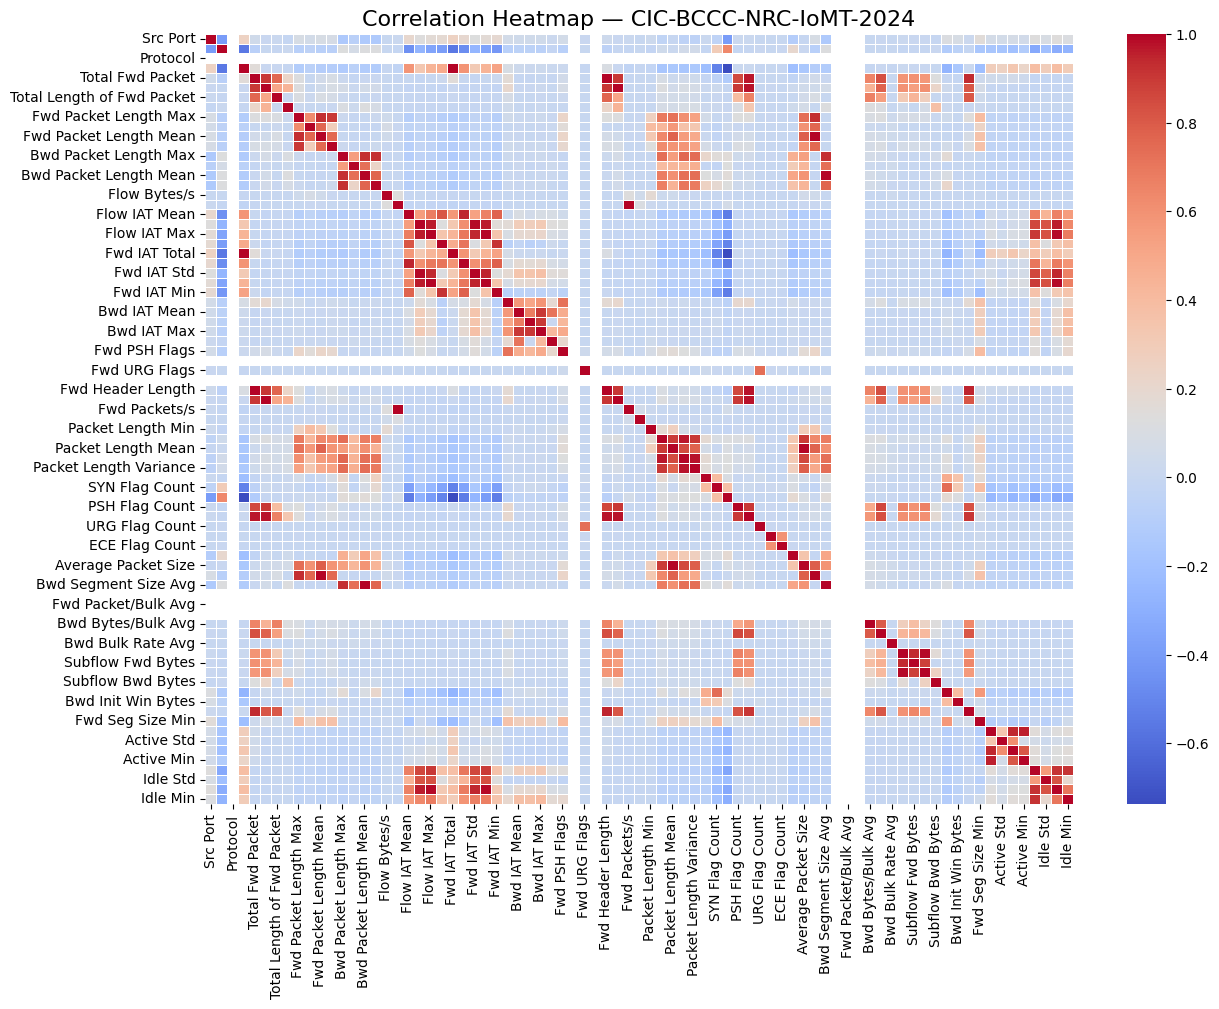

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap — CIC-BCCC-NRC-IoMT-2024", fontsize=16)
plt.show()

## Feature Variance Check

In [ ]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

selector = VarianceThreshold(threshold=0.0)
selector.fit(numeric_df)

constant_features = numeric_df.columns[selector.get_support() == False]

print("🧪 Constant / Zero Variance Features:")
list(constant_features)

🧪 Constant / Zero Variance Features:


['Protocol',
 'Bwd PSH Flags',
 'Bwd URG Flags',
 'Fwd Bytes/Bulk Avg',
 'Fwd Packet/Bulk Avg',
 'Fwd Bulk Rate Avg']

# 5. NETWORK TRAFFIC BEHAVIOR ANALYSIS

## Packet Size Distribution

🔍 Detected Packet-Related Columns: ['Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'Average Packet Size', 'Fwd Segment Size Avg', 'Bwd Segment Size Avg', 'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg', 'Bwd Bytes/Bulk Avg', 'Bwd Packet/Bulk Avg', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'FWD Init Win Bytes', 'Bwd Init Win Bytes', 'Fwd Act Data Pkts', 'Fwd Seg Size Min']

📊 Plotting packet size distribution for: Total Fwd Packet


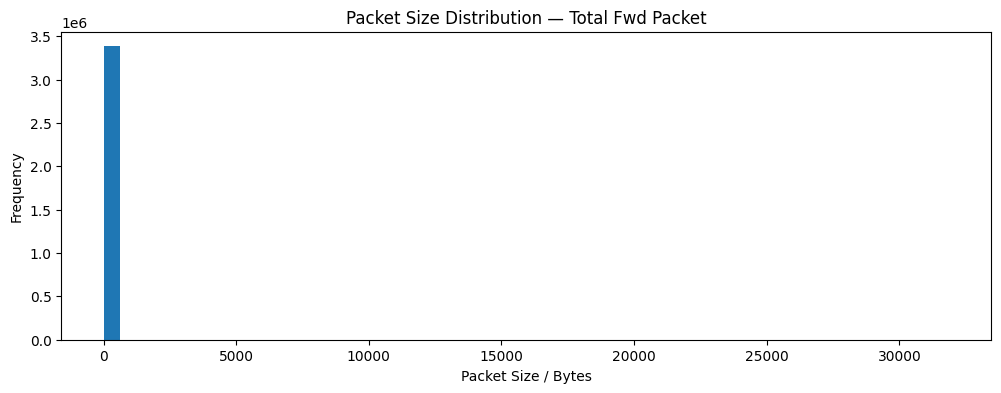

In [ ]:
packet_cols = [c for c in df.columns if
               "packet" in c.lower() or
               "pkt" in c.lower() or
               "size" in c.lower() or
               "bytes" in c.lower()]

print("🔍 Detected Packet-Related Columns:", packet_cols)

if len(packet_cols) == 0:
    print("❌ No packet size related columns detected.")
else:
    col = packet_cols[0]
    print(f"\n📊 Plotting packet size distribution for: {col}")

    df[col].plot(kind="hist", bins=50, figsize=(12,4))
    plt.title(f"Packet Size Distribution — {col}")
    plt.xlabel("Packet Size / Bytes")
    plt.ylabel("Frequency")
    plt.show()

## Flow Duration Distribution

In [ ]:
duration_cols = [c for c in df.columns if
                 "duration" in c.lower() or
                 "flow" in c.lower() and "time" in c.lower() or
                 "flow_time" in c.lower() or
                 "flow_duration" in c.lower()]

print("⏱️ Detected Duration Columns:", duration_cols)

⏱️ Detected Duration Columns: ['Flow Duration']



📊 Plotting flow duration distribution for: Flow Duration


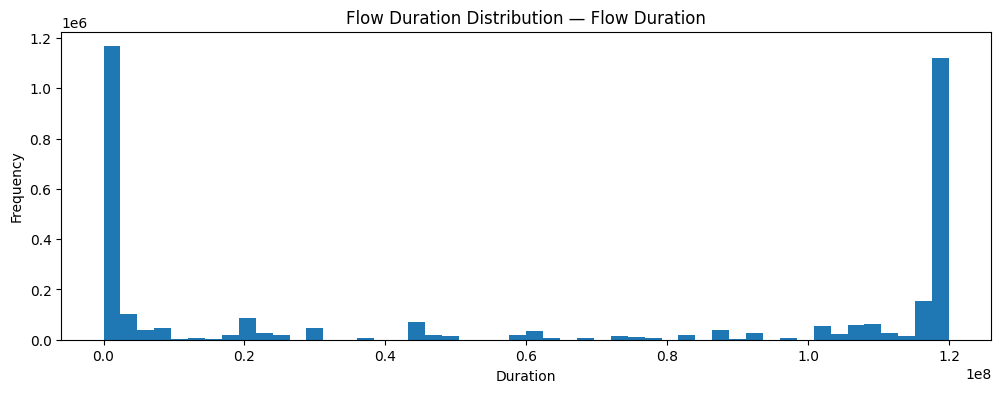

In [ ]:
if len(duration_cols) == 0:
    print("❌ No flow duration related columns detected.")
else:
    col = duration_cols[0]
    print(f"\n📊 Plotting flow duration distribution for: {col}")

    df[col].plot(kind="hist", bins=50, figsize=(12,4))
    plt.title(f"Flow Duration Distribution — {col}")
    plt.xlabel("Duration")
    plt.ylabel("Frequency")
    plt.show()

## Protocol Distribution

In [ ]:
protocol_cols = [c for c in df.columns if
                 "protocol" in c.lower() or
                 "proto" in c.lower()]

print("🌐 Detected Protocol Columns:", protocol_cols)

🌐 Detected Protocol Columns: ['Protocol']



📊 Plotting protocol distribution for: Protocol


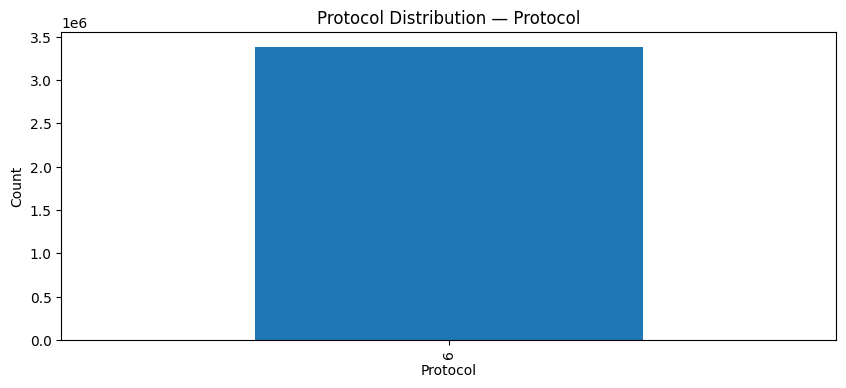

In [ ]:
if len(protocol_cols) == 0:
    print("❌ No protocol-related columns found.")
else:
    col = protocol_cols[0]
    print(f"\n📊 Plotting protocol distribution for: {col}")

    df[col].value_counts().plot(kind="bar", figsize=(10,4))
    plt.title(f"Protocol Distribution — {col}")
    plt.xlabel("Protocol")
    plt.ylabel("Count")
    plt.show()

    df[col].value_counts()

# 6.TIME-BASED ANALYSIS

## Traffic Volume Over Time

In [ ]:
time_cols = [c for c in df.columns if
             "time" in c.lower() or
             "timestamp" in c.lower() or
             "date" in c.lower()]

print("⏱️ Detected Time Columns:", time_cols)

⏱️ Detected Time Columns: ['Timestamp']


/tmp/ipython-input-1874783640.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_time[time_col] = pd.to_datetime(df_time[time_col], errors="coerce")


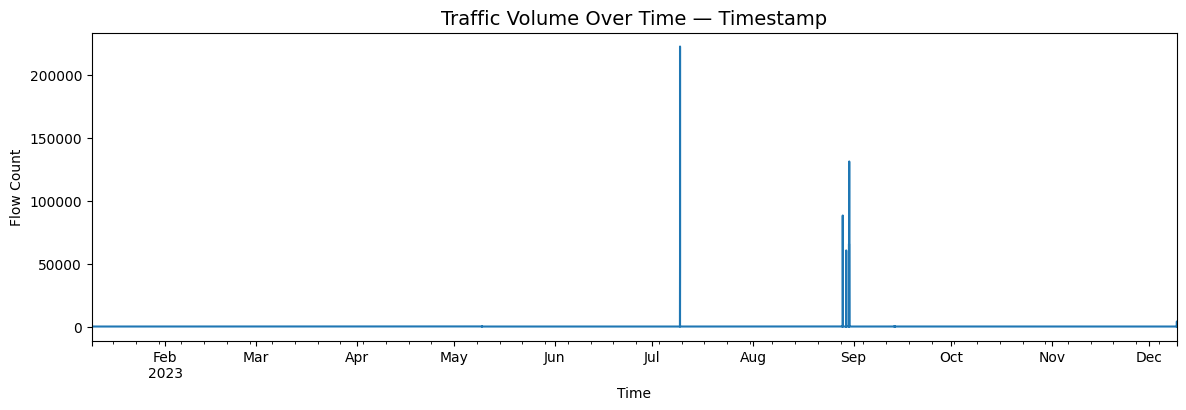

In [ ]:
if len(time_cols) == 0:
    print("❌ No timestamp-like column found. Skipping time-based traffic analysis.")
else:
    time_col = time_cols[0]

    df_time = df.copy()
    df_time[time_col] = pd.to_datetime(df_time[time_col], errors="coerce")

    df_time = df_time.dropna(subset=[time_col])

    # Resample by 1 minute
    traffic_per_min = df_time.set_index(time_col).resample("1min").size()

    plt.figure(figsize=(14,4))
    traffic_per_min.plot()
    plt.title(f"Traffic Volume Over Time — {time_col}", fontsize=14)
    plt.xlabel("Time")
    plt.ylabel("Flow Count")
    plt.show()

    traffic_per_min.head()

## Attack Frequency Over Time

/tmp/ipython-input-169855814.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_attack[time_col] = pd.to_datetime(df_attack[time_col], errors="coerce")


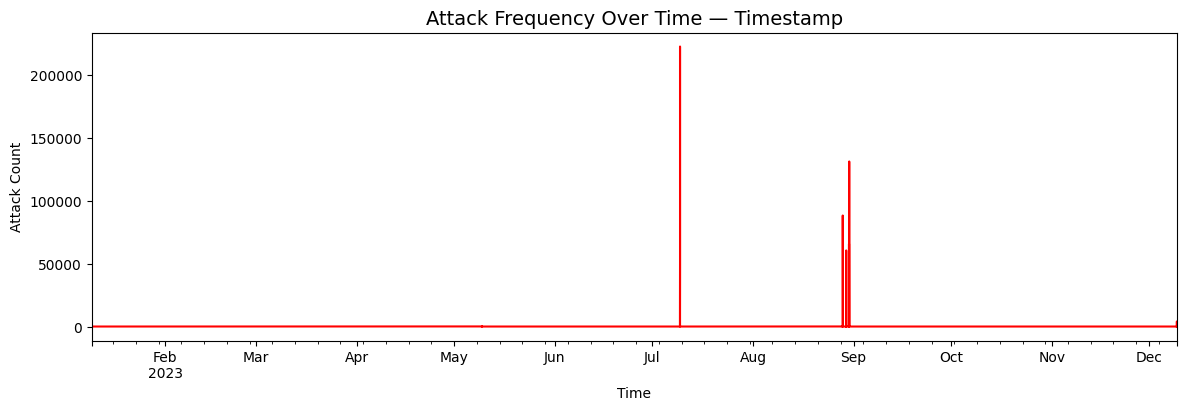

In [ ]:
if len(time_cols) == 0:
    print("❌ Cannot compute attack frequency without a timestamp column.")
else:
    time_col = time_cols[0]

    df_attack = df.copy()
    df_attack[time_col] = pd.to_datetime(df_attack[time_col], errors="coerce")
    df_attack = df_attack.dropna(subset=[time_col])

    # Attack = any class except Benign
    attack_df = df_attack[df_attack["Label"] != "Benign Traffic"]

    # Resample attack counts per minute
    attacks_per_min = attack_df.set_index(time_col).resample("1min").size()

    plt.figure(figsize=(14,4))
    attacks_per_min.plot(color="red")
    plt.title(f"Attack Frequency Over Time — {time_col}", fontsize=14)
    plt.xlabel("Time")
    plt.ylabel("Attack Count")
    plt.show()

    attacks_per_min.head()

# 7. LABEL ENCODING & PREPROCESSING READINESS

## Categorical Feature Check

In [ ]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("🧩 Categorical Columns Detected:")
cat_cols

🧩 Categorical Columns Detected:


['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Attack Name', 'Label']

## Detect Object Columns That Are Actually Numeric

In [ ]:
numeric_like = []

for col in cat_cols:
    try:
        df[col].astype(float)
        numeric_like.append(col)
    except:
        pass

print("🔍 Object Columns That Are Actually Numeric:")
numeric_like

🔍 Object Columns That Are Actually Numeric:


[]

## Preprocessing Summary Checklist

In [ ]:
print("========== PREPROCESSING SUMMARY FOR IoMT-2024 ==========\n")

print(f"Total Features: {len(df.columns)}")
print(f"Numeric Features: {len(df.select_dtypes(include=['float64', 'int64']).columns)}")
print(f"Categorical Features: {len(cat_cols)}\n")

# Missing values from Section 3
missing_cols = missing[missing > 0].index.tolist()
print("🚨 Columns With Missing Values:", missing_cols if missing_cols else "None")

# Constant features from Section 4
print("\n🧪 Constant / Zero-Variance Features:",
      list(constant_features) if len(constant_features) > 0 else "None")

print("\n🧩 Categorical Columns:", cat_cols)
print("🔢 Numeric-like Object Columns:", numeric_like)

print("\n========== NEXT STEPS RECOMMENDATION ==========\n")
print("""
✔ Convert numeric-like object columns to numeric types
✔ Encode categorical features (LabelEncoder / OneHot)
✔ Handle missing values (impute / drop)
✔ Remove constant or near-zero variance features
✔ Remove highly correlated features (>0.95)
✔ Normalize or standardize numerical features
✔ Apply SMOTE or class balancing if class imbalance exists
✔ Prepare final clean dataset for ML/DL model training
""")

print("==========================================================")


========== PREPROCESSING SUMMARY FOR IoMT-2024 ==========

Total Features: 85
Numeric Features: 79
Categorical Features: 6

🚨 Columns With Missing Values: None

🧪 Constant / Zero-Variance Features: ['Protocol', 'Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg', 'Fwd Bulk Rate Avg']

🧩 Categorical Columns: ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Attack Name', 'Label']
🔢 Numeric-like Object Columns: []

========== NEXT STEPS RECOMMENDATION ==========


✔ Convert numeric-like object columns to numeric types
✔ Encode categorical features (LabelEncoder / OneHot)
✔ Handle missing values (impute / drop)
✔ Remove constant or near-zero variance features
✔ Remove highly correlated features (>0.95)
✔ Normalize or standardize numerical features
✔ Apply SMOTE or class balancing if class imbalance exists
✔ Prepare final clean dataset for ML/DL model training



# 8. CROSS-DATASET COMPARISON READINESS

In [ ]:
print("📌 Total Columns:", len(df.columns))

print("\n🧩 Column Names:")
for col in df.columns:
    print(" -", col)

📌 Total Columns: 85

🧩 Column Names:
 - Flow ID
 - Src IP
 - Src Port
 - Dst IP
 - Dst Port
 - Protocol
 - Timestamp
 - Flow Duration
 - Total Fwd Packet
 - Total Bwd packets
 - Total Length of Fwd Packet
 - Total Length of Bwd Packet
 - Fwd Packet Length Max
 - Fwd Packet Length Min
 - Fwd Packet Length Mean
 - Fwd Packet Length Std
 - Bwd Packet Length Max
 - Bwd Packet Length Min
 - Bwd Packet Length Mean
 - Bwd Packet Length Std
 - Flow Bytes/s
 - Flow Packets/s
 - Flow IAT Mean
 - Flow IAT Std
 - Flow IAT Max
 - Flow IAT Min
 - Fwd IAT Total
 - Fwd IAT Mean
 - Fwd IAT Std
 - Fwd IAT Max
 - Fwd IAT Min
 - Bwd IAT Total
 - Bwd IAT Mean
 - Bwd IAT Std
 - Bwd IAT Max
 - Bwd IAT Min
 - Fwd PSH Flags
 - Bwd PSH Flags
 - Fwd URG Flags
 - Bwd URG Flags
 - Fwd Header Length
 - Bwd Header Length
 - Fwd Packets/s
 - Bwd Packets/s
 - Packet Length Min
 - Packet Length Max
 - Packet Length Mean
 - Packet Length Std
 - Packet Length Variance
 - FIN Flag Count
 - SYN Flag Count
 - RST Flag Count

In [ ]:
normalized_features = [c.lower().strip().replace(" ", "_") for c in df.columns]

print("\n🔍 Normalized Column Name Set (for schema alignment):")
set(normalized_features)


🔍 Normalized Column Name Set (for schema alignment):


{'ack_flag_count',
 'active_max',
 'active_mean',
 'active_min',
 'active_std',
 'attack_name',
 'average_packet_size',
 'bwd_bulk_rate_avg',
 'bwd_bytes/bulk_avg',
 'bwd_header_length',
 'bwd_iat_max',
 'bwd_iat_mean',
 'bwd_iat_min',
 'bwd_iat_std',
 'bwd_iat_total',
 'bwd_init_win_bytes',
 'bwd_packet/bulk_avg',
 'bwd_packet_length_max',
 'bwd_packet_length_mean',
 'bwd_packet_length_min',
 'bwd_packet_length_std',
 'bwd_packets/s',
 'bwd_psh_flags',
 'bwd_segment_size_avg',
 'bwd_urg_flags',
 'cwr_flag_count',
 'down/up_ratio',
 'dst_ip',
 'dst_port',
 'ece_flag_count',
 'fin_flag_count',
 'flow_bytes/s',
 'flow_duration',
 'flow_iat_max',
 'flow_iat_mean',
 'flow_iat_min',
 'flow_iat_std',
 'flow_id',
 'flow_packets/s',
 'fwd_act_data_pkts',
 'fwd_bulk_rate_avg',
 'fwd_bytes/bulk_avg',
 'fwd_header_length',
 'fwd_iat_max',
 'fwd_iat_mean',
 'fwd_iat_min',
 'fwd_iat_std',
 'fwd_iat_total',
 'fwd_init_win_bytes',
 'fwd_packet/bulk_avg',
 'fwd_packet_length_max',
 'fwd_packet_length_

## Attack Class Comparison

In [ ]:
unique_classes = df["Label"].unique()

print("📌 Total Classes:", len(unique_classes))
print("\n🛡️ Attack / Traffic Classes Detected:")

for cls in unique_classes:
    print(" -", cls)

📌 Total Classes: 15

🛡️ Attack / Traffic Classes Detected:
 - DDoS ICMP Flood
 - DoS ICMP Flood
 - DDoS UDP Flood
 - DoS TCP Flood
 - Benign Traffic
 - MITM ARP Spoofing
 - DoS UDP Flood
 - MQTT DDoS Publish Flood
 - MQTT Malformed
 - MQTT DoS Publish Flood
 - Recon OS Scan
 - MQTT DoS Connect Flood
 - Recon Port Scan
 - Recon Vulnerability Scan
 - Recon Ping Sweep


# 9. FINAL EDA SUMMARY REPORT

In [ ]:
print("========== FINAL EDA SUMMARY — CIC-BCCC-NRC-IoMT-2024 ==========\n")

# Basic Structure
print(f"📌 Total Rows:\t\t {df.shape[0]:,}")
print(f"📌 Total Columns:\t {df.shape[1]:,}\n")

# Class distribution
print("---- Class Distribution ----")
print(df["Label"].value_counts(), "\n")

# Class percentages
print("---- Class Distribution (%) ----")
print((df["Label"].value_counts(normalize=True) * 100).round(2), "\n")

# Missing values summary
missing_cols = missing[missing > 0].index.tolist()
print("---- Missing Value Columns ----")
print(missing_cols if missing_cols else "No missing values found.", "\n")

# Duplicate summary
print("---- Duplicate Rows ----")
print(f"Total Duplicates: {df.duplicated().sum()}\n")

# Constant / zero variance features
print("---- Constant Features ----")
if len(constant_features) > 0:
    print(list(constant_features))
else:
    print("No constant features detected.\n")

# Categorical features
print("---- Categorical Features ----")
print(cat_cols if len(cat_cols) > 0 else "No categorical features.\n")

# Numeric-like object features
print("---- Object Columns That Are Numeric-like ----")
print(numeric_like if len(numeric_like) > 0 else "None\n")

# Overall counts
num_cols = df.select_dtypes(include=['float64','int64']).columns
print(f"Total Numeric Features:\t\t {len(num_cols)}")
print(f"Total Categorical Features:\t {len(cat_cols)}\n")

print("========== NEXT STEPS RECOMMENDATION ==========\n")
print("""
✔ Convert numeric-like object columns to float
✔ Encode categorical features (LabelEncoder / OneHot)
✔ Handle missing values (if any)
✔ Remove constant / zero-variance features
✔ Remove highly correlated features (> 0.95)
✔ Normalize / standardize numeric features
✔ Use SMOTE or class weights for imbalanced classes
✔ Prepare final machine-learning-ready dataset
""")

print("==============================================================")


========== FINAL EDA SUMMARY — CIC-BCCC-NRC-IoMT-2024 ==========

📌 Total Rows:		 3,385,313
📌 Total Columns:	 85

---- Class Distribution ----
Label
DoS TCP Flood               2106916
Recon Port Scan              485522
MQTT DDoS Publish Flood      413913
MQTT DoS Connect Flood       238031
Recon OS Scan                 85317
Benign Traffic                32620
Recon Vulnerability Scan       8321
DoS UDP Flood                  3115
DDoS UDP Flood                 2576
DDoS ICMP Flood                2552
MQTT Malformed                 2246
DoS ICMP Flood                 2107
MITM ARP Spoofing              1053
MQTT DoS Publish Flood          953
Recon Ping Sweep                 71
Name: count, dtype: int64 

---- Class Distribution (%) ----
Label
DoS TCP Flood               62.24
Recon Port Scan             14.34
MQTT DDoS Publish Flood     12.23
MQTT DoS Connect Flood       7.03
Recon OS Scan                2.52
Benign Traffic               0.96
Recon Vulnerability Scan     0.25
DoS UD

# 10. AUTO-GENERATED DOCX EDA REPORT

## Save directory

In [ ]:
save_dir = "/users/"
os.makedirs(save_dir, exist_ok=True)

save_path = f"{save_dir}/CIC_BCCC_NRC_IoMT_2024_FULL_EDA_REPORT.docx"

doc = Document()

## TITLE

In [ ]:
doc.add_heading("CIC-BCCC-NRC-IoMT-2024 — Full Exploratory Data Analysis Report", 0)
doc.add_paragraph(
    "This document contains a complete exploratory analysis of the CIC-BCCC-NRC-IoMT-2024 dataset, including structure, statistics, class distributions, missing values, duplicates, preprocessing readiness, and metadata."
)

## DATASET OVERVIEW

In [ ]:
doc.add_heading("1. Dataset Overview", level=1)
doc.add_paragraph(f"• Total Rows: {df.shape[0]:,}")
doc.add_paragraph(f"• Total Columns: {df.shape[1]:,}")
doc.add_paragraph(f"• Label Column: Label")

## CLASS DISTRIBUTION

In [ ]:
doc.add_heading("2. Class Distribution", level=1)

class_counts = df["Label"].value_counts()
class_percent = (df["Label"].value_counts(normalize=True) * 100).round(2)

table = doc.add_table(rows=1, cols=3)
hdr = table.rows[0].cells
hdr[0].text = "Class"
hdr[1].text = "Count"
hdr[2].text = "Percentage (%)"

for cls in class_counts.index:
    row = table.add_row().cells
    row[0].text = str(cls)
    row[1].text = str(class_counts[cls])
    row[2].text = str(class_percent[cls])

## DUPLICATE ROW ANALYSIS

In [ ]:
doc.add_heading("3. Duplicate Row Analysis", level=1)
doc.add_paragraph(f"• Total Duplicate Rows: {df.duplicated().sum()}")

## MISSING VALUE ANALYSIS

In [ ]:
doc.add_heading("4. Missing Value Analysis", level=1)

missing_vals = df.isnull().sum()
missing_vals = missing_vals[missing_vals > 0]

if len(missing_vals) > 0:
    table = doc.add_table(rows=1, cols=2)
    h = table.rows[0].cells
    h[0].text = "Feature"
    h[1].text = "Missing Count"

    for col, val in missing_vals.items():
        row = table.add_row().cells
        row[0].text = col
        row[1].text = str(val)
else:
    doc.add_paragraph("No missing values detected.")

## NUMERICAL FEATURE STATISTICS

In [ ]:
doc.add_heading("5. Numerical Feature Statistical Summary", level=1)

num_stats = df.describe().T

table = doc.add_table(rows=1, cols=len(num_stats.columns) + 1)
hdr = table.rows[0].cells
hdr[0].text = "Feature"

for i, col in enumerate(num_stats.columns):
    hdr[i + 1].text = col

for idx in num_stats.index:
    row = table.add_row().cells
    row[0].text = idx
    for i, col in enumerate(num_stats.columns):
        row[i + 1].text = str(round(num_stats.loc[idx, col], 4))

## CONSTANT FEATURES

In [ ]:
doc.add_heading("6. Constant or Zero-Variance Features", level=1)

if len(constant_features) > 0:
    for c in constant_features:
        doc.add_paragraph(f"• {c}")
else:
    doc.add_paragraph("No constant features detected.")

## CATEGORICAL FEATURES

In [ ]:
doc.add_heading("7. Categorical Feature List", level=1)

if len(cat_cols) > 0:
    for c in cat_cols:
        doc.add_paragraph(f"• {c}")
else:
    doc.add_paragraph("No categorical features detected.")

## CORRELATION INSIGHTS

In [ ]:
doc.add_heading("8. Correlation Insights", level=1)
doc.add_paragraph(
    "Correlation heatmap (generated in notebook) suggests removing features with correlation > 0.95 to reduce multicollinearity."
)

## PREPROCESSING SUMMARY

In [ ]:
doc.add_heading("9. Preprocessing Summary", level=1)

doc.add_paragraph("Recommended preprocessing steps:")
steps = [
    "Convert numeric-like object columns to float",
    "Encode categorical features (LabelEncoder / OneHot)",
    "Handle missing values (if any)",
    "Remove constant or near-zero variance features",
    "Remove highly correlated features (>0.95)",
    "Normalize / standardize numeric features",
    "Balance dataset using SMOTE or class weights",
    "Prepare final ML-ready dataset",
]

for s in steps:
    doc.add_paragraph(f"✔ {s}")

## FULL METADATA SNAPSHOT

In [ ]:
doc.add_heading("10. Full Dataset Metadata Snapshot", level=1)

meta_table = doc.add_table(rows=1, cols=3)
hdr = meta_table.rows[0].cells
hdr[0].text = "Feature"
hdr[1].text = "Data Type"
hdr[2].text = "Unique Count"

for col in df.columns:
    row = meta_table.add_row().cells
    row[0].text = col
    row[1].text = str(df[col].dtype)
    row[2].text = str(df[col].nunique())

## SAVE DOCUMENT

In [ ]:
doc.save(save_path)
print(f"📄 EDA Report Generated Successfully:\n{save_path}")

📄 EDA Report Generated Successfully:
/users/
